# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [140]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [141]:
df = pd.read_csv("data\\AviationData_Cleaned.csv")

The client wants an analysis on data that is 40 years old. 

This means the dataframe needs to be filtered for data from the year 1983 onwards.

The column Event.Date needs to be changed to Date time and then the dataframe is filtered.

In [142]:
df["Event.Date"] = pd.to_datetime(df["Event.Date"])
df = df[df["Event.Date"].dt.year >= 1983]


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

A column called Plane.Size will be created ant it will indicate the size of the plane based off of the number of passengers.

If the number of passenges bellow 20, the plane is a small plane. If not, it is a large plane

In [143]:
df["Plane.Size"] = np.where((df["Total.Passengers"] < 20), "Small", "Large")


The column Plane.Size can have inconsistencies if there are flights that have the same Plane.Type, but different Total.Passengers. 

For example, if one flight has less than 20 passengers and another has more than 20 passengers but the same Plane.Type, then that Plane.Type will occur as both a "Large" and "Small".

Since the client is interested in knowing what types of airctrafts exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident, each Plane.Type should only be associated with one Plane.Size and not multiple. 

To ensure this, if a plane is categorized as both "Small" and "Large", all the rows where that sepecific Plane.Type is occuring will have their value in Plane.Size set to "Large"

In [144]:
inconsistent_size = df.groupby("Plane.Type")["Plane.Size"].nunique()
inconsistent_size = inconsistent_size[inconsistent_size > 1].index
df["Plane.Size"] = np.where(df["Plane.Type"].isin(inconsistent_size), "Large", df["Plane.Size"])

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

A new column called Injusry.Fraction which contains the proportioin of passangers who were fataly or seriously injured

The values in this column are  = (Total.Fatal.Injuries + Total.Serious.Injuries) / Total.Passengers



In [145]:
df['Injury_Fraction'] = (df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']) / df['Total.Passengers']

To calculate the mean of the column Injury.Fraction for "Small" and "Large" makes, we have to group by Make and Plane.Size

To avoid skewing the average, there need to be at least 5 accidents per Make Plane.Size combination

In [146]:
make_group = df.groupby(['Make', 'Plane.Size'])
make_stats = make_group['Injury_Fraction'].agg(['mean', 'count']).reset_index()

# Renaming Mean and Count columns
make_stats.columns = ['Make', 'Plane.Size', 'mean_injury_fraction', 'accident_count']
make_stats = make_stats[make_stats['accident_count'] >= 5]

In [147]:
small_top15 = make_stats[make_stats['Plane.Size'] == 'Small'].nsmallest(15, 'mean_injury_fraction')
large_top15 = make_stats[make_stats['Plane.Size'] == 'Large'].nsmallest(15, 'mean_injury_fraction')
combined = pd.concat([small_top15, large_top15])

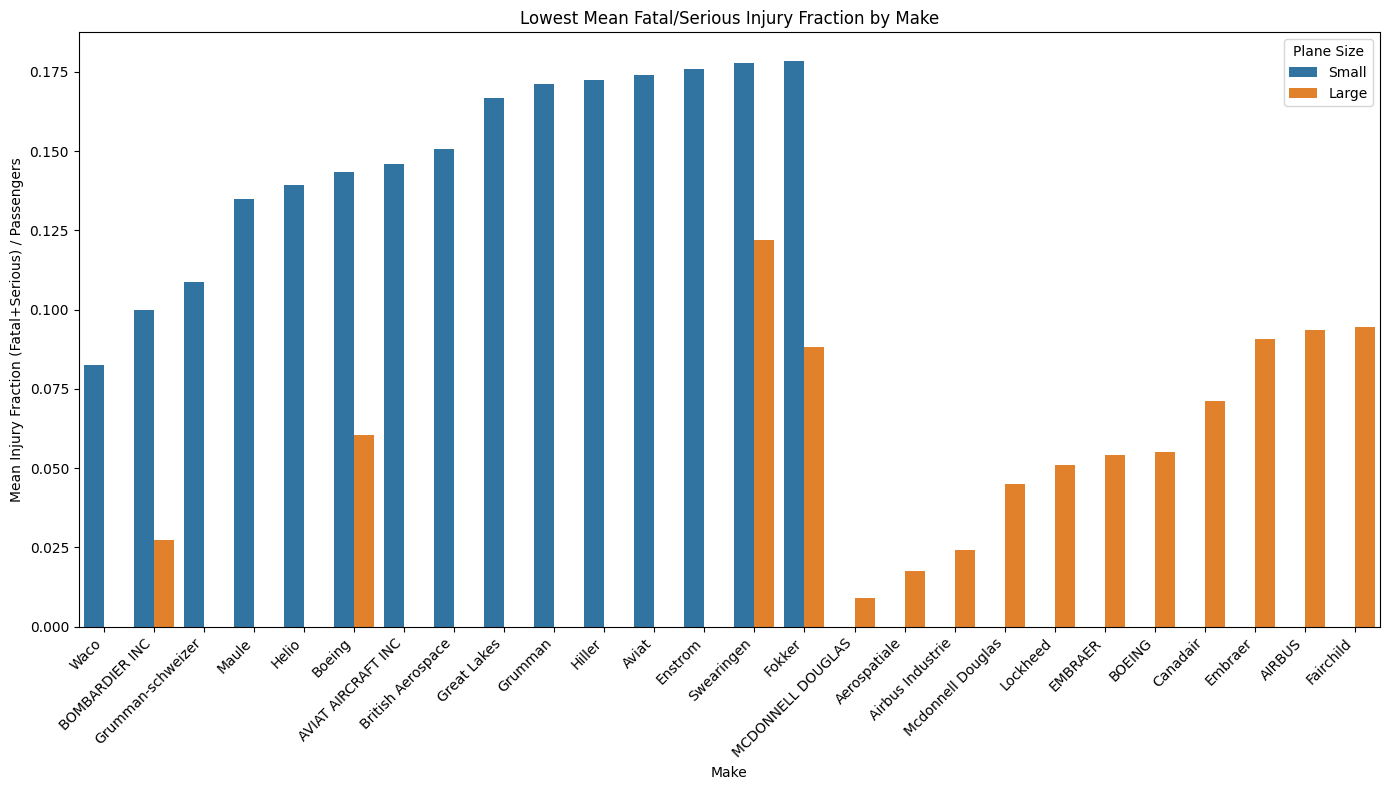

In [148]:
plt.figure(figsize=(14, 8))
sns.barplot(data=combined, x='Make', y='mean_injury_fraction', hue='Plane.Size', dodge= True)
plt.title('Lowest Mean Fatal/Serious Injury Fraction by Make')
plt.ylabel('Mean Injury Fraction (Fatal+Serious) / Passengers')
plt.xlabel('Make')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Plane Size')
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

To do this, the dataframe will have to be filtered for small planes.

To calculate mean and count, we will group by the make and the filter the for rows where count > 5 in order to reduce the impact of outliers.

In [149]:
small_planes = df[df['Plane.Size'] == 'Small']

small_make_stats = small_planes.groupby('Make')['Injury_Fraction'].agg(['mean', 'count']).reset_index()
small_make_stats.columns = ['Make', 'mean_injury_fraction', 'accident_count']

small_make_stats = small_make_stats[small_make_stats['accident_count'] >= 5]

top10_makes = list(small_make_stats.nsmallest(10, 'mean_injury_fraction')['Make'])

Violin plot showing the full distribution of Injury_Fraction per accident for each of the 10 safest small makes.

The width shows density; narrow parts indicate fewer observations at that injury level.

C:\Users\Shaun Raymond\AppData\Local\Temp\ipykernel_16640\1126741389.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Make', y='Injury_Fraction', palette='muted')


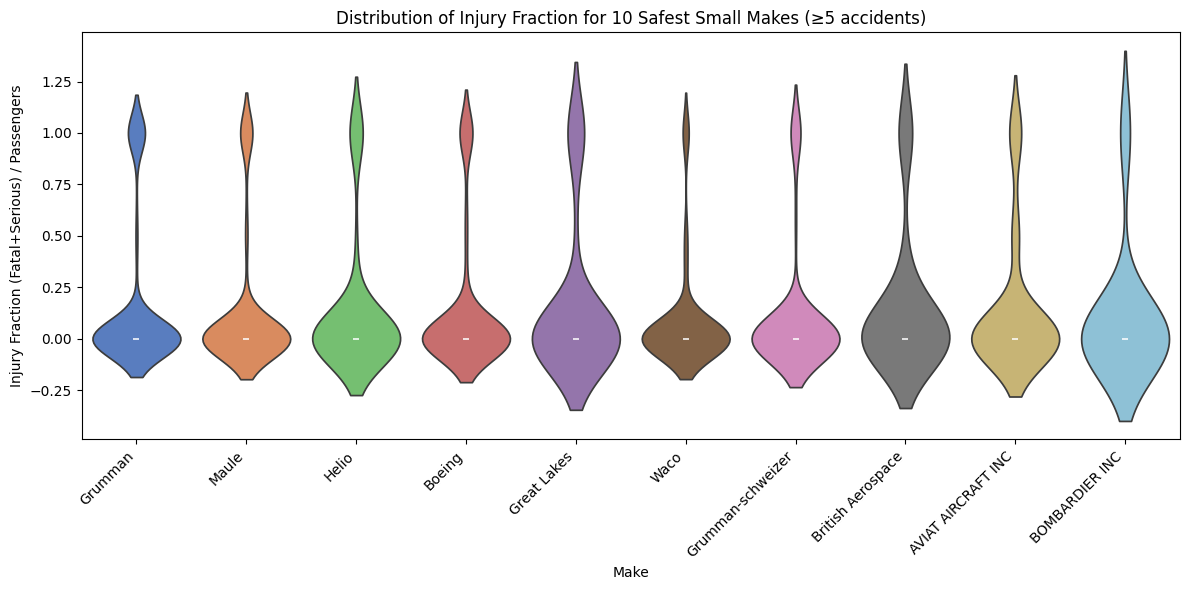

In [150]:
plot_data = small_planes[small_planes['Make'].isin(top10_makes)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=plot_data, x='Make', y='Injury_Fraction', palette='muted')
plt.title('Distribution of Injury Fraction for 10 Safest Small Makes (≥5 accidents)')
plt.ylabel('Injury Fraction (Fatal+Serious) / Passengers')
plt.xlabel('Make')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [151]:
large_planes = df[df['Plane.Size'] == 'Large']

#calculate mean Injury.Fraction and accident count for each make and filter out makes with less than 5 accidents.
large_group = large_planes.groupby('Make')['Injury_Fraction']
large_stats = pd.DataFrame({
    'mean_injury_fraction': large_group.mean(),
    'accident_count': large_group.count()
}).reset_index()

large_stats_filtered = large_stats[large_stats['accident_count'] >= 5]

top10_large_makes = list(large_stats_filtered.nsmallest(10, 'mean_injury_fraction')['Make'])

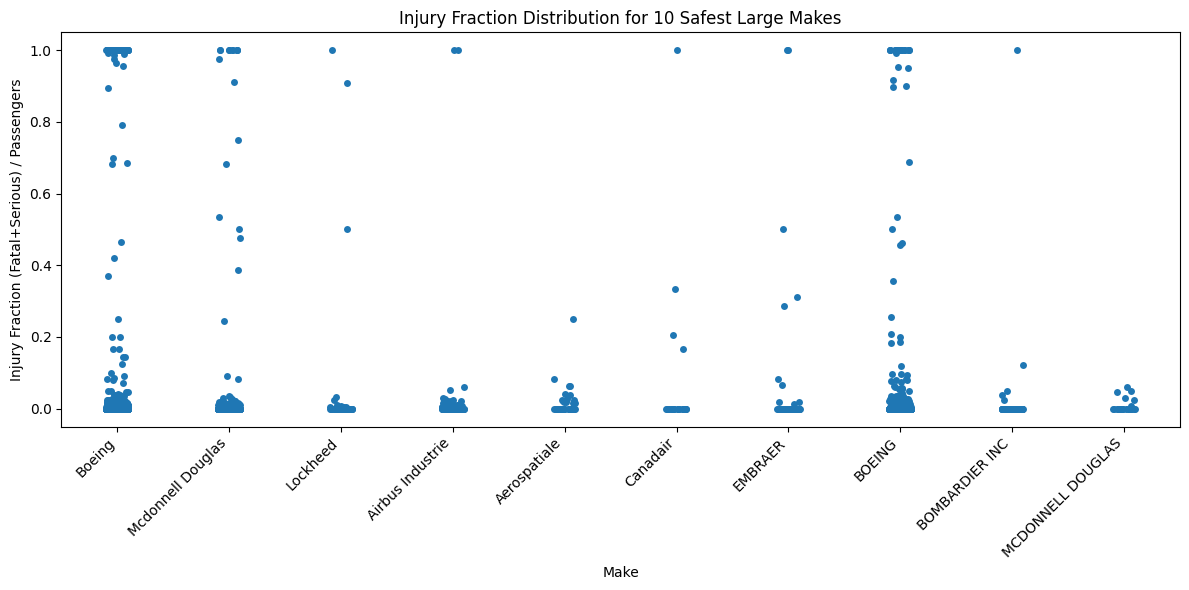

In [152]:
plot_data = large_planes[large_planes['Make'].isin(top10_large_makes)]

plt.figure(figsize=(12, 6))
sns.stripplot(data=plot_data, x='Make', y='Injury_Fraction', jitter=True)
plt.title('Injury Fraction Distribution for 10 Safest Large Makes')
plt.ylabel('Injury Fraction (Fatal+Serious) / Passengers')
plt.xlabel('Make')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

The destruction rate is the proportion of accidents where aircraft was destroyed

In [153]:
destruction_group = df.groupby(['Make', 'Plane.Size'])
destruction_stats = destruction_group['Is.Destroyed'].agg(['mean', 'count']).reset_index()
destruction_stats.columns = ['Make', 'Plane.Size', 'destruction_rate', 'accident_count']

destruction_stats = destruction_stats[destruction_stats['accident_count'] >= 5]

small_destr = destruction_stats[destruction_stats['Plane.Size'] == 'Small'].nsmallest(15, 'destruction_rate')
large_destr = destruction_stats[destruction_stats['Plane.Size'] == 'Large'].nsmallest(15, 'destruction_rate')
combined_dest = pd.concat([small_destr, large_destr])

combined_dest.sort_values(['Plane.Size', 'destruction_rate'])

,Make,Plane.Size,destruction_rate,accident_count
10,Aerospatiale,Large,0.000000,40
60,EMBRAER,Large,0.016393,61
25,BOMBARDIER INC,Large,0.022222,45
14,Airbus Industrie,Large,0.029126,103
23,BOEING,Large,0.037106,539
98,MCDONNELL DOUGLAS,Large,0.041667,24
39,CESSNA,Large,0.054299,221
103,Mcdonnell Douglas,Large,0.061584,341
33,Boeing,Large,0.065000,1000
63,Embraer,Large,0.065574,61


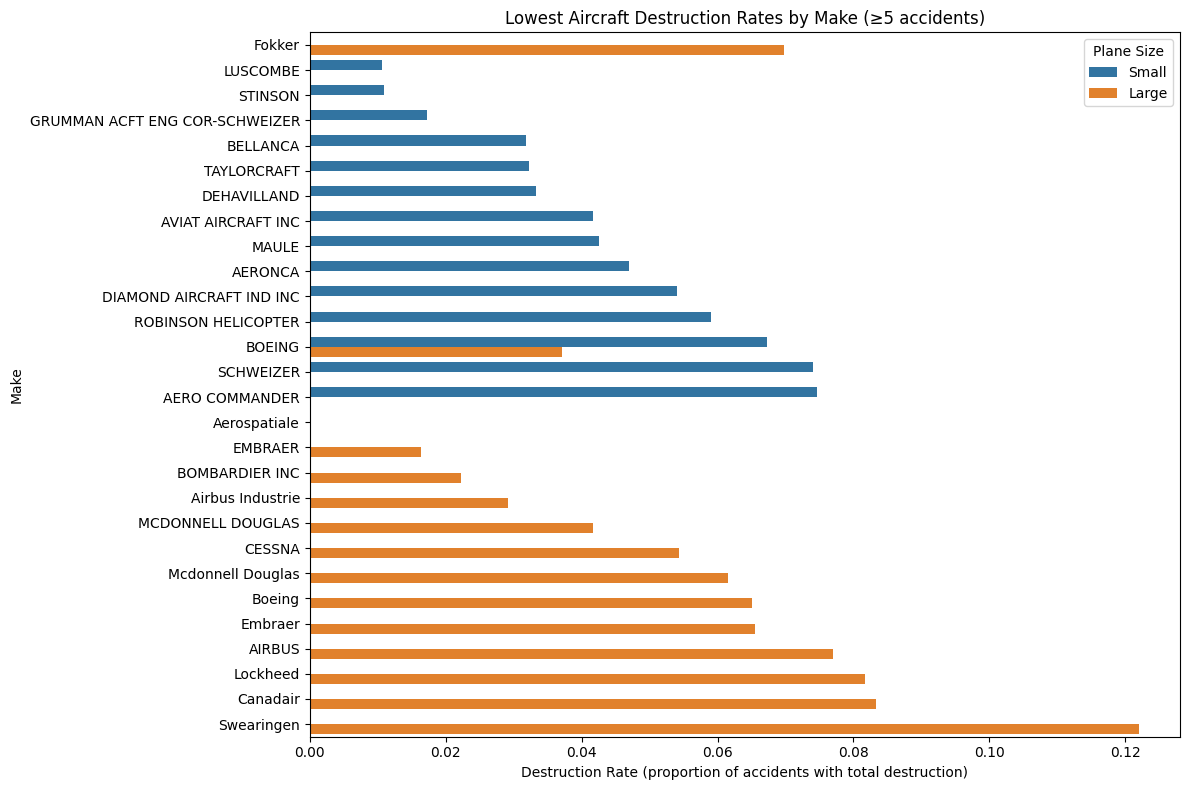

In [154]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=combined_dest,
    x='destruction_rate',
    y='Make',
    hue='Plane.Size',
    dodge=True,
    orient='h'
)
plt.title('Lowest Aircraft Destruction Rates by Make (≥5 accidents)')
plt.xlabel('Destruction Rate (proportion of accidents with total destruction)')
plt.ylabel('Make')
plt.legend(title='Plane Size')
plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

**Findings for Makes (Small vs. Large)**

**Lowest Injury Fractions:**

For **small aircraft**, the safest makes (lowest mean injury fraction) were: 
* Waco
* Bombardier INC
* Grumman-scheizer
* Maule
* Helio

For **large aircraft**, the safest makes were: 
* Aerospatiale
* Airbus Industrie
* McDonnell Douglas 
* BOMBARDIER INC
* Lockheed

**Distribution Spread:**

* The *small makes* violin plot showed that most accidents for safe makes had injury fractions near 0.

* However, some had outliers reaching around 1.0

* This suggests that even safe small makes can have rare severe events.

* The *large makes* stripplot showed tighter clustering around 0 for the top makes, with fewer extreme outliers compared to small planes.



**Lowest Destruction Rates:**

* For **small** aircraft, the 15 lowest destruction rates ranged from approximately 0.01 (LUSCOMBE, STINSON) to approximately 0.074 (AERO COMMANDER).

* For **large** aircraft, the 15 lowest destruction rates ranged from approximately 0.017 (EMBRAER) to approximately 0.122 (Swearingen).

* Large aircraft generally have higher destruction rates than small ones, likely due to more robust construction and safety systems.



**Recommendations:**

* For **small aircraft** insurance, recommend: Waco, Grumman-schweizer, Maule, Helio, and Boeing based on consistently low injury fractions and destruction rates.

* For **large aircraft** insurance, recommend: Aerospatiale, BOMBARDIER INC, Airbus Industrie, McDonnell Douglas, and Lockheed based on tight injury distributions and very low destruction rates.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [155]:
large_planes = df[df['Plane.Size'] == 'Large']

large_type_group = large_planes.groupby('Plane.Type')['Injury_Fraction']
large_type_stats = pd.DataFrame({
    'mean_injury_fraction': large_type_group.mean(),
    'accident_count': large_type_group.count()
}).reset_index()

large_type_stats = large_type_stats[large_type_stats['accident_count'] >= 10]

large_type_stats will be sorted in ascending order to make it easier to read the plot.

C:\Users\Shaun Raymond\AppData\Local\Temp\ipykernel_16640\1801850610.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=large_type_stats, x='Plane.Type', y='mean_injury_fraction', palette='viridis')


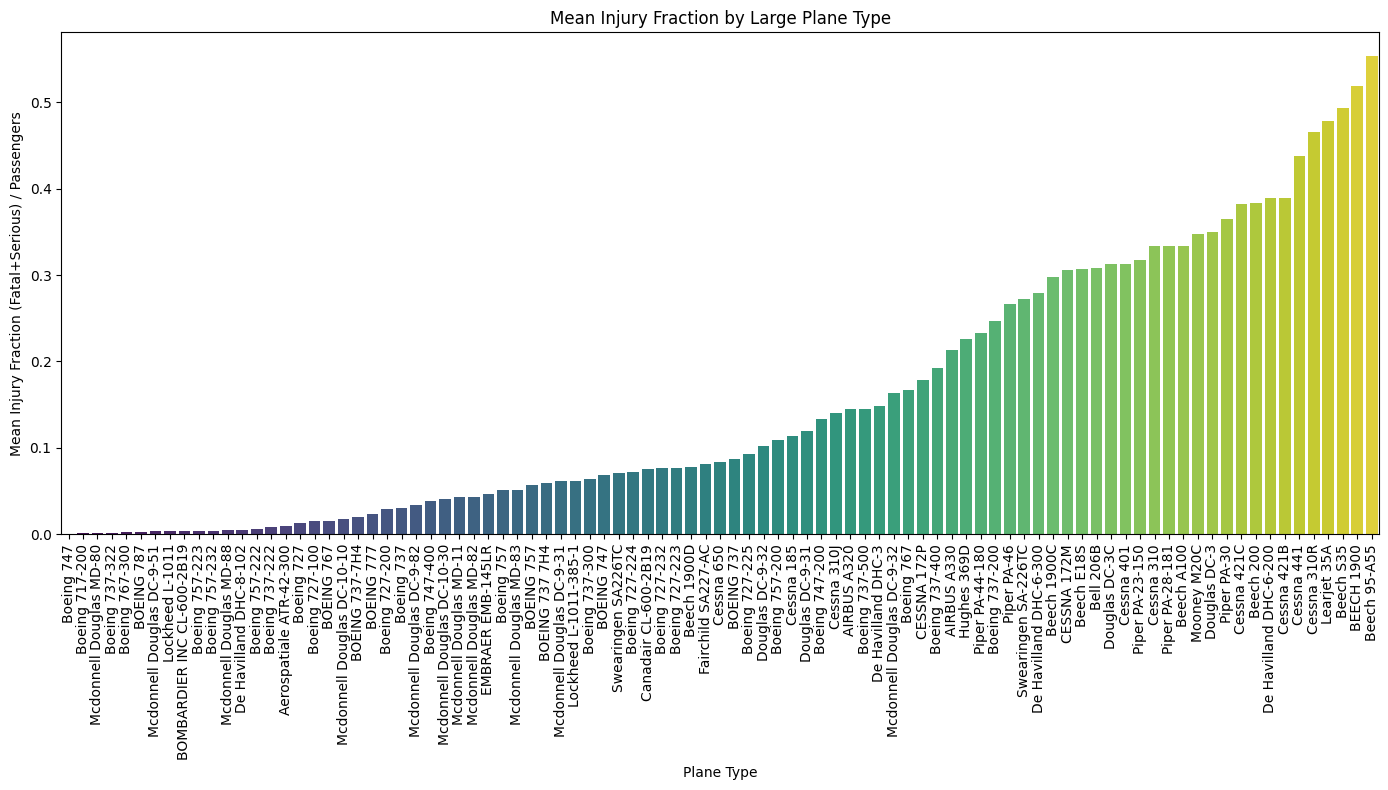

In [156]:
large_type_stats = large_type_stats.sort_values('mean_injury_fraction')

plt.figure(figsize=(14, 8))
sns.barplot(data=large_type_stats, x='Plane.Type', y='mean_injury_fraction', palette='viridis')
plt.title('Mean Injury Fraction by Large Plane Type')
plt.ylabel('Mean Injury Fraction (Fatal+Serious) / Passengers')
plt.xlabel('Plane Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [157]:
small_planes = df[df['Plane.Size'] == 'Small']

small_type_group = small_planes.groupby('Plane.Type')['Injury_Fraction']
small_type_stats = pd.DataFrame({
    'mean_injury_fraction': small_type_group.mean(),
    'accident_count': small_type_group.count()
}).reset_index()

small_type_stats = small_type_stats[small_type_stats['accident_count'] >= 10]

top10_small_types = small_type_stats.nsmallest(10, 'mean_injury_fraction')
top10_small_list = top10_small_types['Plane.Type'].tolist()

C:\Users\Shaun Raymond\AppData\Local\Temp\ipykernel_16640\1326271787.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_small_types, x='Plane.Type', y='mean_injury_fraction', palette='viridis')


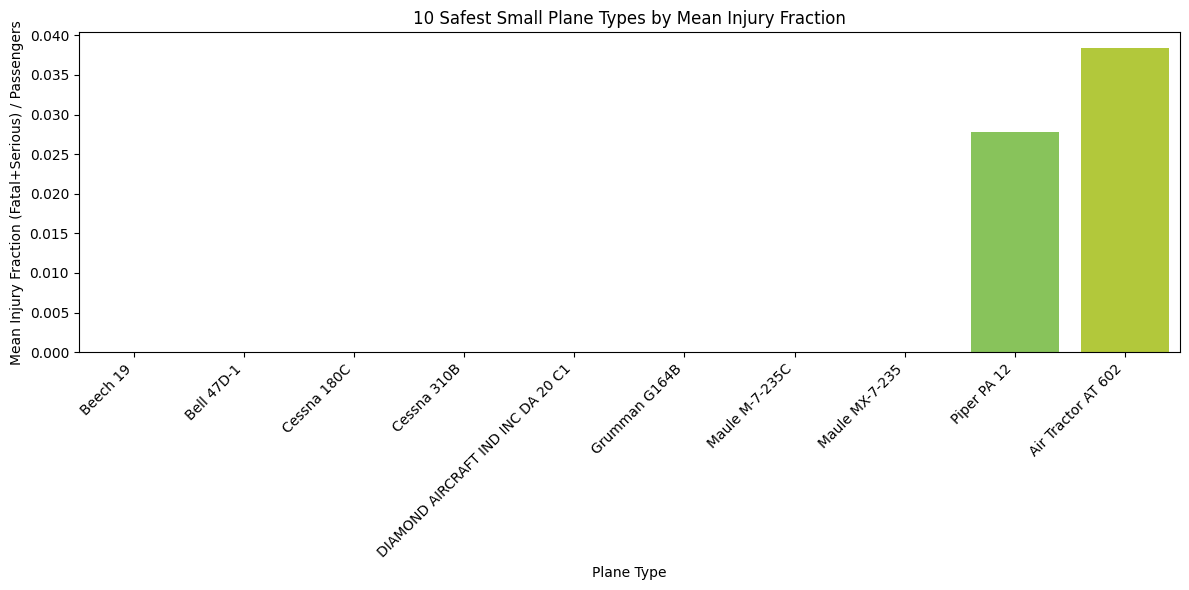

In [158]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top10_small_types, x='Plane.Type', y='mean_injury_fraction', palette='viridis')
plt.title('10 Safest Small Plane Types by Mean Injury Fraction')
plt.ylabel('Mean Injury Fraction (Fatal+Serious) / Passengers')
plt.xlabel('Plane Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\Shaun Raymond\AppData\Local\Temp\ipykernel_16640\2529529996.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=temp, x='Plane.Type', y='Injury_Fraction', palette='viridis')


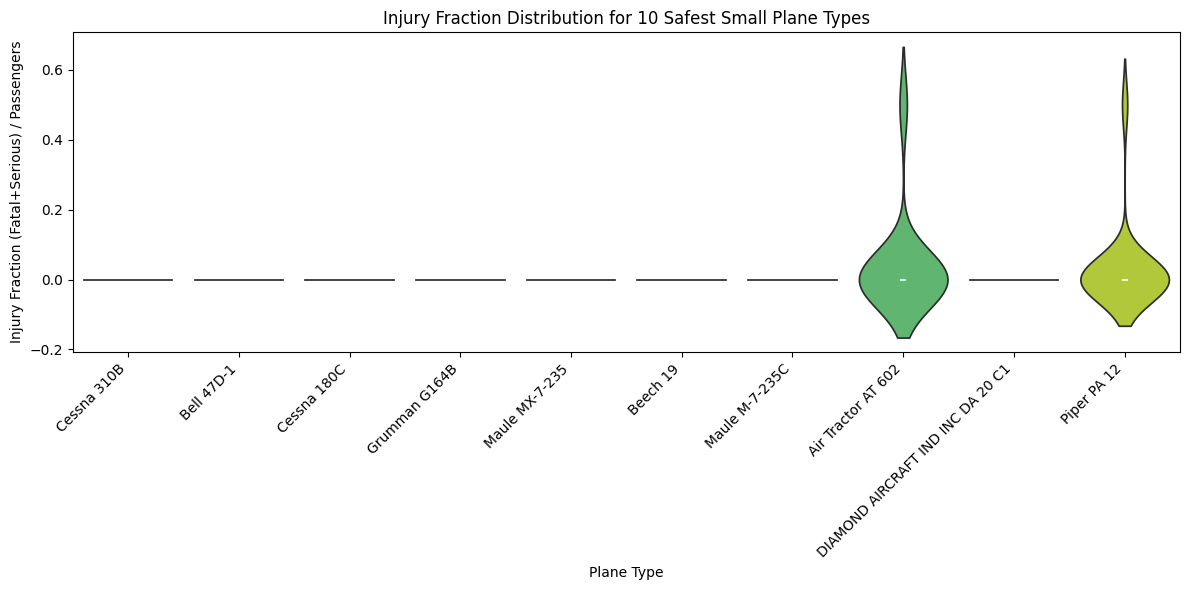

In [159]:
temp = small_planes[small_planes['Plane.Type'].isin(top10_small_list)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=temp, x='Plane.Type', y='Injury_Fraction', palette='viridis')
plt.title('Injury Fraction Distribution for 10 Safest Small Plane Types')
plt.ylabel('Injury Fraction (Fatal+Serious) / Passengers')
plt.xlabel('Plane Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

**Findings for Specific Plane Types (Small vs. Large)**

**Lowest Injury Fractions:**

* For large aircraft, the safest plane types (lowest mean injury fraction) were: Boeing 747-200, Boeing 747-400, Boeing 767-300, McDonnell Douglas MD-80, and Boeing 737-300. 
Their injury fractions ranged from approximately 0.00 to 0.01

* For small aircraft, the 10 safest plane types were: Beech 19, Bell 47D-1, Cessna 180C, Cessna 310B, DIAMOND AIRCRAFT IND INC DA 20 C1, Grumman G164B, Maule M-7-235C, Maule MX-7-235, Piper PA-12, and Air Tractor AT 602. Their injury fractions ranged from approximately 0.000 to 0.038.

**Distribution Spread:**
* For large plane types, the bar chart shows that the safest types have mean injury fractions clustered near 0.00, while some types at the high end have mean fractions approaching 0.55, suggesting much more severe outcomes. 
* For small plane types, the violin plot reveals that even the safest types have some variability — Air Tractor AT 602 and Piper PA-12 show notably wide distributions , while the other eight types are tightly clustered at 0. This suggests that individual accidents can still be severe even for generally safe planes.

**Recommendations for Specific Aircraft:**
* Recommended large passenger models are: Boeing 747-200, Boeing 747-400, Boeing 767-300, McDonnell Douglas MD-80, and Boeing 737-300 – these combine the lowest visible mean injury rates in the analysis.
* Recommended **Small aircraft** Beech 19, Bell 47D-1, Cessna 180C, Cessna 310B, DIAMOND AIRCRAFT IND INC DA 20 C1, Grumman G164B, Maule M-7-235C, and Maule MX-7-235 – these have consistently near-zero injury fractions with tight, flat distributions indicating stable performance across multiple accidents.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.